In [2]:
import os
print(os.listdir("/content"))

['.config', 'sample_data']


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("train.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.shape

(891, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df = df.drop(columns=["Cabin"])

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
df["Survived"].mean()

np.float64(0.3838383838383838)

In [12]:
df.groupby("Sex")["Survived"].mean()

,Survived
Sex,
female,0.742038
male,0.188908


In [13]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


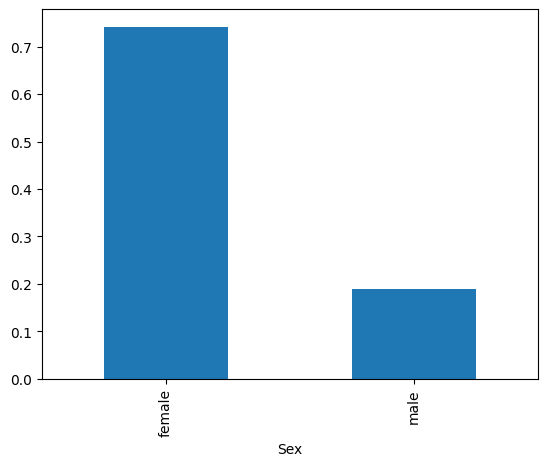

In [14]:
import matplotlib.pyplot as plt

df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.show()

In [15]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [16]:
df = pd.get_dummies(df, columns=["Embarked"], dtype=int)

In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,0,1


In [18]:
df = df.drop(columns=["PassengerId", "Name", "Ticket"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,1,38.0,1,0,71.2833,1,0,0
2,1,3,1,26.0,0,0,7.9250,0,0,1
3,1,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,0,1


In [19]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [22]:
X.shape,y.shape

((891, 9), (891,))

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape, X_test.shape

((712, 9), (179, 9))

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
model.score(X_test, y_test)

0.8100558659217877

In [27]:
preds = model.predict(X_test)
print(preds[:10])
print(y_test.values[:10])

[0 0 0 1 1 1 1 0 1 1]
[1 0 0 1 1 1 1 0 1 1]


In [28]:
(preds == y_test.values).mean()

np.float64(0.8100558659217877)

In [29]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf.score(X_test, y_test)

0.8100558659217877

In [30]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

,0
Sex,0.279648
Fare,0.256427
Age,0.251878
Pclass,0.091026
SibSp,0.047176
Parch,0.035335
Embarked_S,0.015578
Embarked_C,0.013317
Embarked_Q,0.009614


In [31]:
raw = pd.read_csv("train.csv")
df["Title"] = raw["Name"].str.extract(r", (\w+)\.")
df["Title"].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Mlle,2
Major,2
Col,2


In [32]:
df.groupby("Title")["Survived"].agg(["mean", "count"])

,mean,count
Title,,
Capt,0.000000,1
Col,0.500000,2
Don,0.000000,1
Dr,0.428571,7
Jonkheer,0.000000,1
Lady,1.000000,1
Major,0.500000,2
Master,0.575000,40
Miss,0.697802,182


In [33]:
common = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(common), "Other")
df = pd.get_dummies(df, columns=["Title"], dtype=int)


In [34]:
X = df.drop(columns=["Survived"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Logistic:", model.score(X_test, y_test))

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("Random Forest:", rf.score(X_test, y_test))

Logistic: 0.8100558659217877
Random Forest: 0.8268156424581006


In [35]:
from sklearn.model_selection import cross_val_score

print("Logistic:", cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5).mean())
print("Random Forest:", cross_val_score(RandomForestClassifier(random_state=42), X, y, cv=5).mean())

Logistic: 0.8260247316552632
Random Forest: 0.8024794425961961
